In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from imblearn.over_sampling import SMOTE

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = "/content/drive/MyDrive/merged_flight_weather.csv"

In [5]:
data = pd.read_csv(path)

In [6]:
def time_to_seconds(time_str):
    """Convert time in HHMMSS format to total seconds."""
    try:
        h, m, s = int(time_str[:2]), int(time_str[2:4]), int(time_str[4:])
        return h * 3600 + m * 60 + s
    except ValueError:
        return 0  # Handle invalid time strings

data['CRSDepTime'] = data['CRSDepTime'].astype(str).apply(time_to_seconds)

In [7]:
features = ['CRSArrTime', 'WindSpeedKmph', 'WindDirDegree', 'WeatherCode',
            'precipMM', 'Visibilty', 'Pressure', 'Cloudcover', 'DewPointF',
            'WindGustKmph', 'tempF', 'WindChillF', 'Humidity', 'Year',
            'Quarter', 'Month', 'DayofMonth', 'CRSDepTime', 'DepDelayMinutes']

In [8]:
clas_target = 'ArrDel15'
reg_target = 'ArrDelayMinutes'
data = data.fillna(0)

In [9]:
X = data[features]
y = data[clas_target]

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)
X_test, y_test = sm.fit_resample(X_test, y_test)

In [12]:
import joblib

In [13]:
rf = joblib.load("/content/drive/MyDrive/Models/xgboost.pkl")

In [14]:
y_pred = rf.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

In [16]:
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.92


In [17]:
filtered_indices = np.where(data['ArrDel15'] == 1)[0]

In [18]:
filtered_indices

array([      7,       9,      33, ..., 1877285, 1877292, 1877293])

In [19]:
filtered_data = data.iloc[filtered_indices]

In [20]:
filtered_data

,Year,Quarter,Month,DayofMonth,date_x,Origin,Dest,CRSDepTime,DepTime,DepDelayMinutes,...,Pressure,Cloudcover,DewPointF,WindGustKmph,tempF,WindChillF,Humidity,date_y,time,airport
7,2016,1,1,1,2016-01-01,LAS,IAH,0,227.0,117.0,...,1028,0,17,26,29,21,59,2016-01-01,00:00:00,LAS
9,2016,1,1,1,2016-01-01,SEA,ORD,0,112.0,42.0,...,1033,0,23,8,36,32,58,2016-01-01,00:00:00,SEA
33,2016,1,1,1,2016-01-01,ORD,DFW,0,811.0,191.0,...,1024,55,16,33,20,6,87,2016-01-01,05:00:00,ORD
85,2016,1,1,1,2016-01-01,LAS,LAX,0,557.0,0.0,...,1028,0,14,18,26,18,63,2016-01-01,06:00:00,LAS
88,2016,1,1,1,2016-01-01,EWR,LAX,0,628.0,28.0,...,1019,100,32,19,33,27,96,2016-01-01,06:00:00,EWR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1877274,2017,4,12,31,2017-12-31,DFW,LAS,0,5.0,56.0,...,1039,91,6,27,24,12,45,2017-12-31,23:00:00,DFW
1877282,2017,4,12,31,2017-12-31,DFW,PHX,0,43.0,73.0,...,1039,91,6,27,24,12,45,2017-12-31,23:00:00,DFW
1877285,2017,4,12,31,2017-12-31,LAX,SEA,0,58.0,83.0,...,1020,77,54,6,55,55,97,2017-12-31,23:00:00,LAX
1877292,2017,4,12,31,2017-12-31,LAX,DFW,0,143.0,104.0,...,1020,77,54,6,55,55,97,2017-12-31,23:00:00,LAX


In [21]:
reg_target = 'ArrDelayMinutes'
reg_features = features
X_reg = filtered_data[reg_features]
y_reg = filtered_data[reg_target]

In [22]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [23]:
xgb = joblib.load("/content/drive/MyDrive/Models/random_forest_regressor.pkl")

In [24]:
y_reg_pred = xgb.predict(X_reg_test)

In [25]:
r2_c= r2_score(y_reg_test, y_reg_pred)

In [26]:
r2_c

0.9162510104980709

In [27]:
reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb)
])

In [28]:
reg_pipeline.fit(X_reg_train, y_reg_train)
y_pred_reg = reg_pipeline.predict(X_reg_test)

In [29]:
mse = mean_squared_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)
mae = mean_absolute_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mse)
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MSE: 291.09
R2 Score: 0.95
MAE: 11.78
RMSE: 17.06


In [32]:
intervals = [(15,100),(100,200),(200,500),(500,1000),(1000,2000)]

In [33]:
intervals_labels = ['15-100','100-200','200-500','500-1000','1000-2000']

In [42]:
metrics = []

In [51]:
for start,end in intervals:
  interval_data = filtered_data[(filtered_data['ArrDelayMinutes'] >= start) & (filtered_data['ArrDelayMinutes'] < end)]
  frequency = len(interval_data)
  print(f"Frequency of {start}-{end}: {frequency}")
  X_interval = interval_data[reg_features]
  y_interval = interval_data[reg_target]
  reg_pipe  = reg_pipeline.fit(X_interval, y_interval)
  y_pred_interval = reg_pipe.predict(X_interval)

  if frequency > 0:
    mse_interval = mean_squared_error(y_interval, y_pred_interval)
    r2_interval = r2_score(y_interval, y_pred_interval)
    mae_interval = mean_absolute_error(y_interval, y_pred_interval)
    rmse_interval = np.sqrt(mse_interval)
    print(f"MSE: {mse_interval:.6f}")
    print(f"R2 Score: {r2_interval:.6f}")
    print(f"MAE: {mae_interval:.6f}")
    print(f"RMSE: {rmse_interval:.6f}")

    metrics.append({'Start': start,
                    'End': end,
                    'Frequency': frequency,
                    'MSE': mse_interval,
                    'R2': r2_interval,
                    'MAE': mae_interval,
                    'RMSE': rmse_interval
                    })

  metrics_df = pd.DataFrame(metrics)

Frequency of 15-100: 323567
MSE: 171.909023
R2 Score: 0.645404
MAE: 9.805083
RMSE: 13.111408
Frequency of 100-200: 48955
MSE: 213.763983
R2 Score: 0.707465
MAE: 11.062212
RMSE: 14.620670
Frequency of 200-500: 14232
MSE: 285.084362
R2 Score: 0.934739
MAE: 12.310893
RMSE: 16.884441
Frequency of 500-1000: 1129
MSE: 73.194901
R2 Score: 0.996265
MAE: 6.484590
RMSE: 8.555402
Frequency of 1000-2000: 173
MSE: 162.596853
R2 Score: 0.994030
MAE: 8.177554
RMSE: 12.751347


In [66]:
graph_intervals = [(0,100),(100,200),(200,300),(300,400),(400,500),(500,600),(600,700),(700,800),(800,900),(900,1000)]

In [67]:
graph_interval_labels = ['0-100','100-200','200-300','300-400','400-500','500-600','600-700','700-800','800-900','900-1000']

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

actual_values = []
predicted_values = []

for start, end in graph_intervals:
    interval_data = filtered_data[(filtered_data['ArrDelayMinutes'] >= start) &
                                  (filtered_data['ArrDelayMinutes'] < end)]
    if interval_data.empty:
        continue
    X_interval = interval_data[reg_features]
    y_interval = interval_data[reg_target]
    reg_pipe.fit(X_interval, y_interval)
    y_pred = reg_pipe.predict(X_interval)
    actual_values.extend(y_interval)
    predicted_values.extend(y_pred)

df = pd.DataFrame({'Actual': actual_values, 'Predicted': predicted_values})

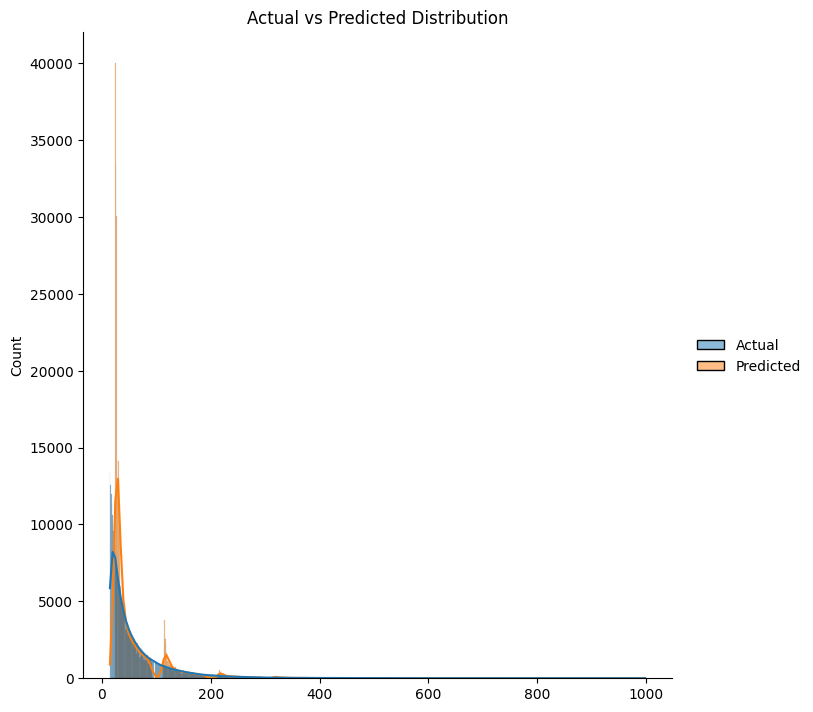

In [72]:
sns.displot(df, kde=True,height=7
            , aspect=1)
plt.title("Actual vs Predicted Distribution")
plt.show()

In [65]:
#plt.plot(actual_values, label="Actual", color="blue")
#plt.plot(predicted_values, label="Predicted", color="red")
#plt.legend()
#plt.title("Actual vs Predicted Values")
#plt.show()

In [74]:
graph_intervals = [(0,100),(100,200),(200,300),(300,400),(400,500)]

In [75]:
graph_interval_labels = ['0-100','100-200','200-300','300-400','400-500']

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

actual_values = []
predicted_values = []

for start, end in graph_intervals:
    interval_data = filtered_data[(filtered_data['ArrDelayMinutes'] >= start) &
                                  (filtered_data['ArrDelayMinutes'] < end)]
    if interval_data.empty:
        continue
    X_interval = interval_data[reg_features]
    y_interval = interval_data[reg_target]
    reg_pipe.fit(X_interval, y_interval)
    y_pred = reg_pipe.predict(X_interval)
    actual_values.extend(y_interval)
    predicted_values.extend(y_pred)

df = pd.DataFrame({'Actual': actual_values, 'Predicted': predicted_values})

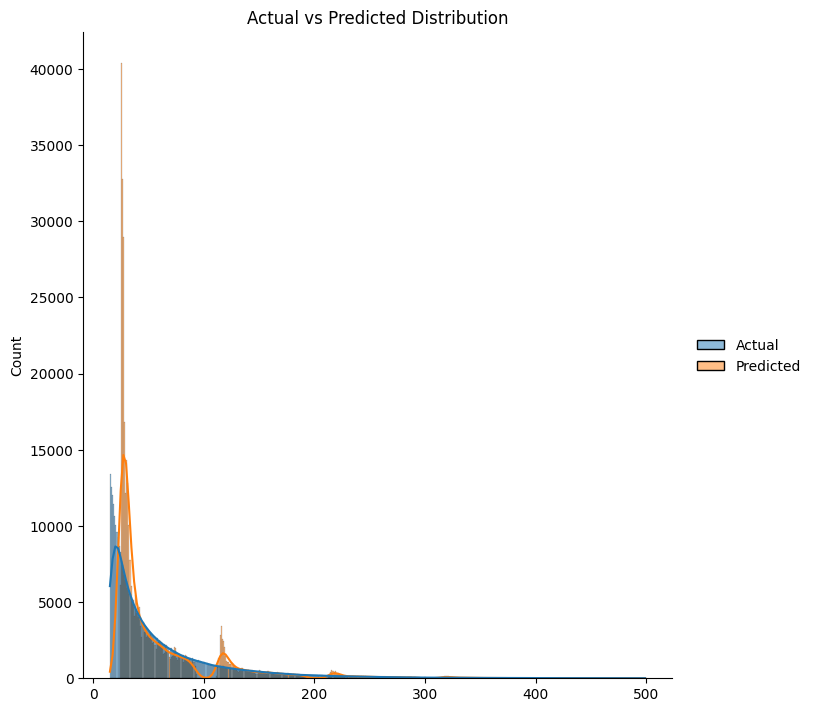

In [77]:
sns.displot(df, kde=True,height=7
            , aspect=1)
plt.title("Actual vs Predicted Distribution")
plt.show()